<a href="https://colab.research.google.com/github/athirasivadas94-glitch/MachineLearningMiniProject-/blob/main/Machine_Learning_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Machine Learning Project





Title of ML Project: Predicting Medical Appointment No-Shows Using Machine Learning Techniques

Name: Athira Sivadas

Organization: Entri Elevate

Date:


**1. Overview of Problem Statement**

Missed medical appointments, known as no-shows, are a common problem in healthcare systems. When patients fail to attend their scheduled appointments, it leads to wasted medical resources, longer waiting times for other patients, and reduced efficiency in hospital operations.

The aim of this project is to predict whether a patient will attend or miss a scheduled medical appointment using machine learning techniques. By analyzing historical appointment data such as patient demographics, medical conditions, and appointment details, patterns related to no-shows can be identified.

The predictive model developed in this project can help healthcare providers identify patients who are likely to miss appointments, allowing them to take preventive measures such as sending reminders or rescheduling appointments to improve healthcare service efficiency.

**2. Objective**

The main objective of this project is to develop a machine learning model that predicts whether a patient will attend or miss a scheduled medical appointment. By analyzing historical appointment data, the project aims to identify key factors influencing no-shows and help healthcare providers improve scheduling efficiency and reduce missed appointments

**3. Data Description**

**Source:**

The dataset used in this project is the Medical Appointment No-Shows Dataset, obtained from Kaggle and provided as a CSV file.
Dataset link: https://www.kaggle.com/datasets/joniarroba/noshowappointments

**Features: **

| Feature        | Description                                                    |
| -------------- | -------------------------------------------------------------- |
| PatientId      | Unique identification number of the patient                    |
| AppointmentID  | Unique identification number for each appointment              |
| Gender         | Gender of the patient (Male/Female)                            |
| ScheduledDay   | Date when the appointment was scheduled                        |
| AppointmentDay | Actual date of the appointment                                 |
| Age            | Age of the patient                                             |
| Neighbourhood  | Location where the hospital is situated                        |
| Scholarship    | Indicates whether the patient is enrolled in a welfare program |
| Hipertension   | Indicates if the patient has hypertension                      |
| Diabetes       | Indicates if the patient has diabetes                          |
| Alcoholism     | Indicates if the patient has alcoholism                        |
| Handcap        | Indicates whether the patient has a disability                 |
| SMS_received   | Indicates whether the patient received an SMS reminder         |

**Target Variable: **

No-show – This is the output variable that indicates whether the patient attended the appointment (No) or missed the appointment (Yes).

**4. Data Preprocessing & Cleaning**

In [ ]:
# Import Required Libraries

import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
# Load Dataset Using Pandas

# Load the dataset
df = pd.read_csv("KaggleV2-May-2016.csv")

# Display first 5 rows
print(df.head())

         PatientId  AppointmentID Gender          ScheduledDay  \
0   29872499824296        5642903      F  2016-04-29T18:38:08Z   
1  558997776694438        5642503      M  2016-04-29T16:08:27Z   
2    4262962299951        5642549      F  2016-04-29T16:19:04Z   
3     867951213174        5642828      F  2016-04-29T17:29:31Z   
4    8841186448183        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0         

In [ ]:
#Check Dataset Information

# Shape of dataset
print(df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

(110527, 14)
Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   PatientId       110527 non-null  int64 
 1   AppointmentID   110527 non-null  int64 
 2   Gender          110527 non-null  object
 3   ScheduledDay    110527 non-null  object
 4   AppointmentDay  110527 non-null  object
 5   Age             110527 non-null  int64 
 6   Neighbourhood   110527 non-null  object
 7   Scholarship     110527 non-null  int64 
 8   Hipertension    110527 non-null  int64 
 9   Diabetes        110527 non-null  int64 
 10  Alcoholism      110527 non-null  int64 
 11  Handcap         110527 non-null  int64 
 12  SMS_

In [ ]:
# Check Missing Values

# Check for missing values
print(df.isnull().sum())

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


The dataset was checked for missing or null values using data inspection methods. Since the dataset contained no significant missing values, no imputation was required.

In [ ]:
# Basic Statistical Summary

# Summary statistics
print(df.describe())

          PatientId  AppointmentID            Age    Scholarship  \
count  1.105270e+05   1.105270e+05  110527.000000  110527.000000   
mean   1.474963e+14   5.675305e+06      37.088874       0.098266   
std    2.560949e+14   7.129575e+04      23.110205       0.297675   
min    3.921800e+04   5.030230e+06      -1.000000       0.000000   
25%    4.172614e+12   5.640286e+06      18.000000       0.000000   
50%    3.173184e+13   5.680573e+06      37.000000       0.000000   
75%    9.439172e+13   5.725524e+06      55.000000       0.000000   
max    9.999816e+14   5.790484e+06     115.000000       1.000000   

        Hipertension       Diabetes     Alcoholism        Handcap  \
count  110527.000000  110527.000000  110527.000000  110527.000000   
mean        0.197246       0.071865       0.030400       0.022248   
std         0.397921       0.258265       0.171686       0.161543   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       

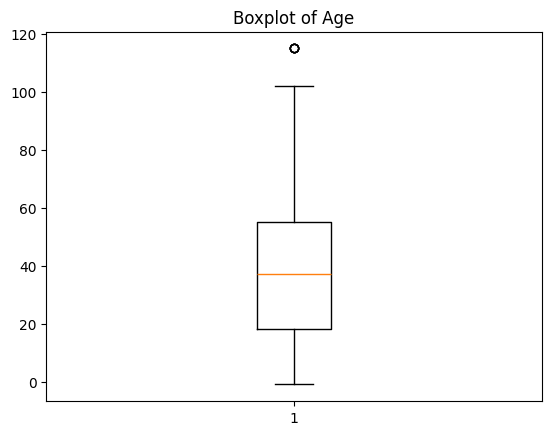

In [ ]:
#Outlier Detection
# Boxplot to detect outliers
plt.boxplot(df['Age'])
plt.title("Boxplot of Age")
plt.show()

No significant outliers

**5 Feature Engineering**


In [ ]:
# Convert Date Columns

df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay']).dt.normalize()
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.normalize()

In [ ]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,29872499824296,5642903,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438,5642503,M,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951,5642549,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174,5642828,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183,5642494,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
#  Create Useful Feature (Waiting Days)

df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

In [ ]:
df[df['WaitingDays'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays
27033,7839272661752,5679978,M,2016-05-10 00:00:00+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,Yes,-1
55226,7896293967868,5715660,F,2016-05-18 00:00:00+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,Yes,-1
64175,24252258389979,5664962,F,2016-05-05 00:00:00+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,Yes,-1
71533,998231581612122,5686628,F,2016-05-11 00:00:00+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,Yes,-6
72362,3787481966821,5655637,M,2016-05-04 00:00:00+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,Yes,-1


In [ ]:
# 1 Handle negative WaitingDays

# Inspect rows where WaitingDays is negative
print("Rows with negative WaitingDays:")
print(df[df['WaitingDays'] < 0].shape)

# For simplicity, we will drop these rows as they are likely data entry errors.
df = df[df['WaitingDays'] >= 0]

print("\nShape of DataFrame after dropping rows with negative WaitingDays:")
print(df.shape)

Rows with negative WaitingDays:
(5, 15)

Shape of DataFrame after dropping rows with negative WaitingDays:
(110522, 15)


In [ ]:
# Check Skewness for a WaitingDays Column
df['WaitingDays'].skew()

np.float64(2.665895975880355)

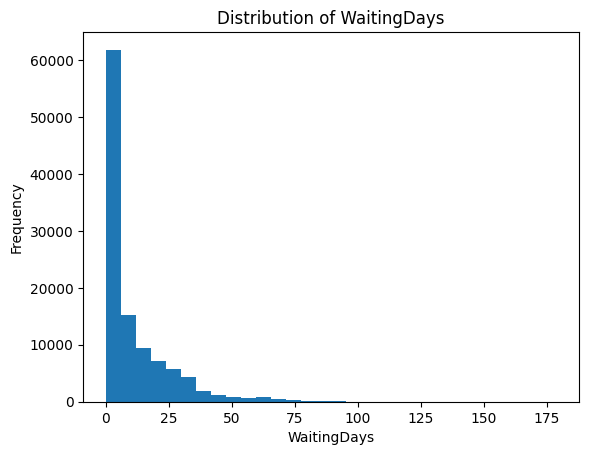

In [ ]:

plt.hist(df['WaitingDays'], bins=30)
plt.title("Distribution of WaitingDays")
plt.xlabel("WaitingDays")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Apply log transformation to reduce skewness
df['WaitingDays'] = np.log1p(df['WaitingDays'])

The log1p() function is used because it safely handles zero values by computing log(1 + x).

By reducing skewness, the transformed data becomes more normally distributed, which can help improve the performance and stability of machine learning models

In [ ]:
# Encode Categorical Variables

le = LabelEncoder()

# Encode Gender
df['Gender'] = le.fit_transform(df['Gender'])

# Encode target variable
df['No-show'] = df['No-show'].map({'No':0, 'Yes':1})


Machine learning algorithms require numerical input, so categorical variables in the dataset were converted into numerical form.

In this dataset, the Gender and No-show columns are categorical. The Gender column was converted using label encoding, where Female = 0 and Male = 1. The No-show column, which represents the target variable, was also encoded where No = 0 (patient attended) and Yes = 1 (patient missed the appointment).

**6. Exploratory Data Analysis (EDA)**

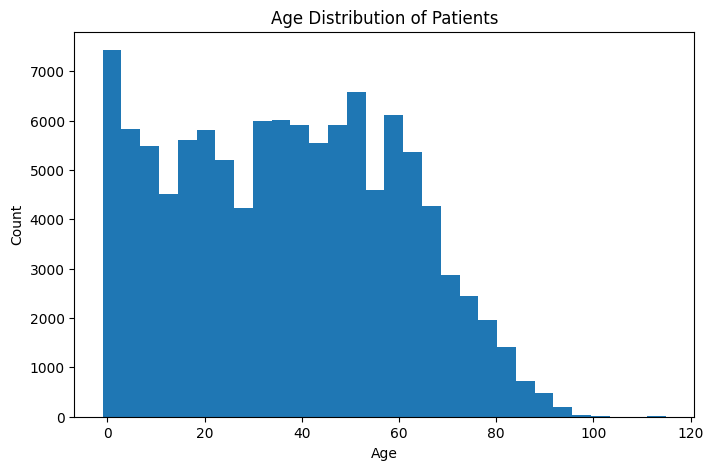

In [ ]:
#6.1  Histogram (Age Distribution)

plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=30)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Insight:
Most patients are between 0-60 years old, with fewer elderly patients.

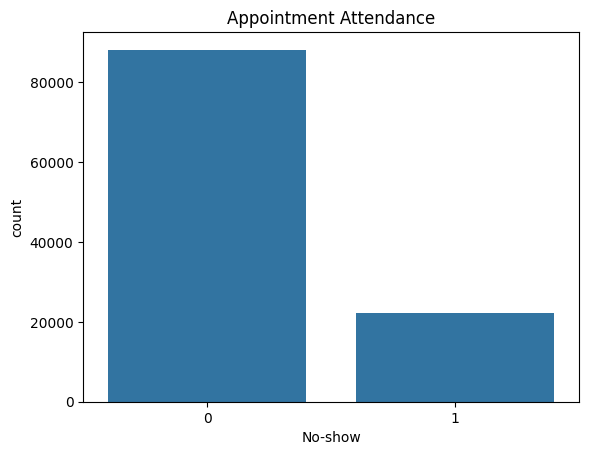

In [ ]:
#6.2. Count Plot (No-show Distribution)

sns.countplot(x='No-show', data=df)
plt.title("Appointment Attendance")
plt.show()

Insight:
Most patients attend their appointments, while a smaller percentage miss them.

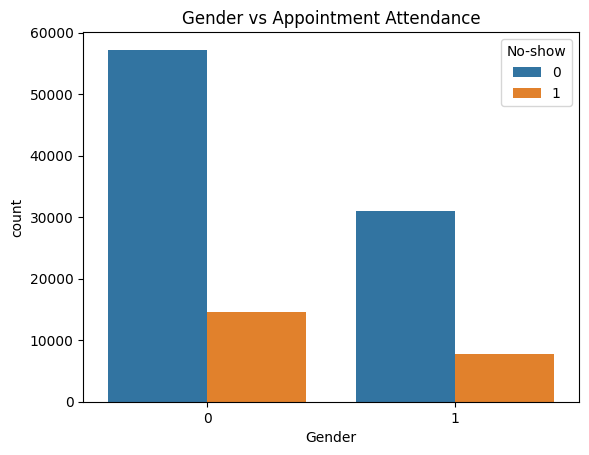

In [ ]:
#6.3. Bar Plot (Gender vs No-show)

sns.countplot(x='Gender', hue='No-show', data=df)
plt.title("Gender vs Appointment Attendance")
plt.show()

Insight:
Both genders attend appointments similarly, though female patients appear slightly more frequently in the dataset.

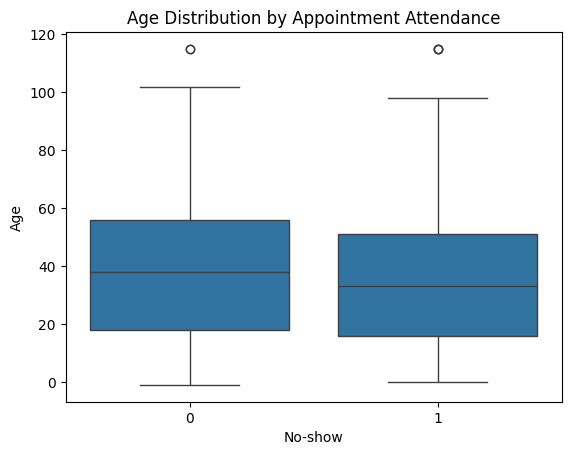

In [ ]:
#6.4. Box Plot (Age vs No-show)

sns.boxplot(x='No-show', y='Age', data=df)
plt.title("Age Distribution by Appointment Attendance")
plt.show()

Insight:
Patients across all age groups miss appointments, but younger adults show slightly higher variability.

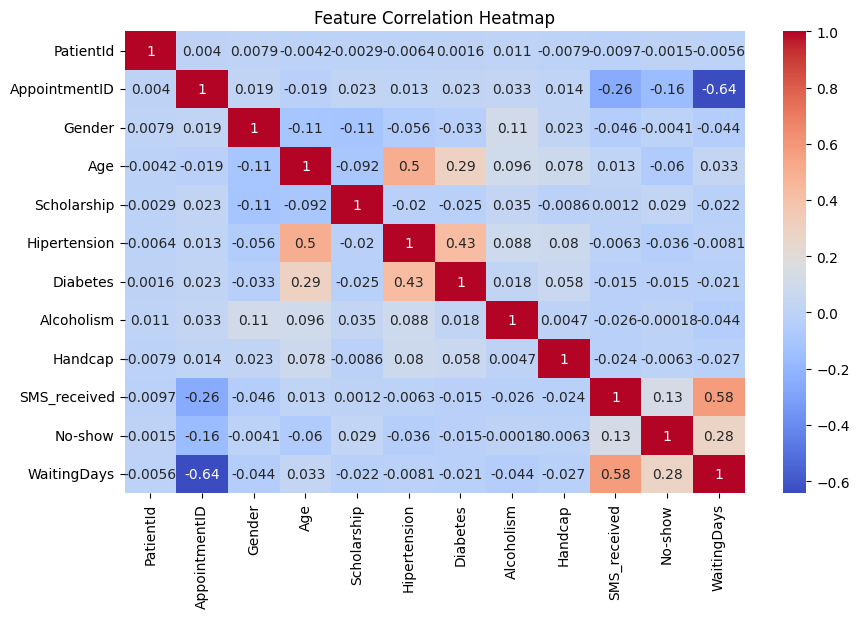

In [ ]:
#6.5. Heatmap Correlation

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Insight:
Most variables show weak correlation, meaning appointment attendance likely depends on multiple combined factors.

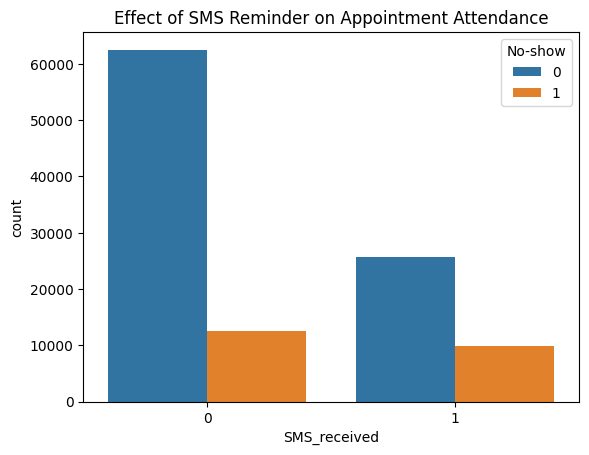

In [ ]:
#6.6. SMS Reminder vs No-show

sns.countplot(x='SMS_received', hue='No-show', data=df)
plt.title("Effect of SMS Reminder on Appointment Attendance")
plt.show()

Insight:
Patients who received SMS reminders tend to attend appointments more frequently, suggesting reminders may reduce no-shows.

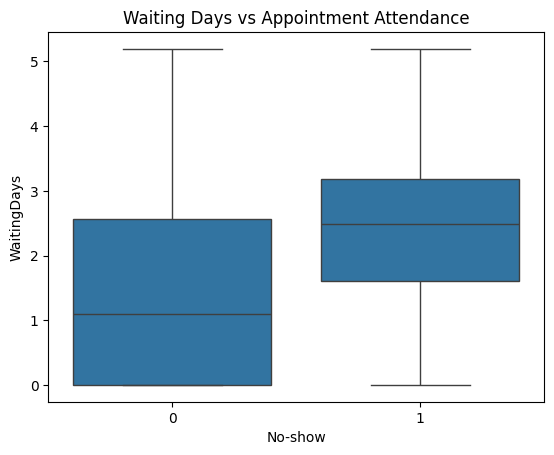

In [ ]:
#6.7. BoxPlot-Waiting Days vs No-Show

sns.boxplot(x='No-show', y='WaitingDays', data=df)
plt.title("Waiting Days vs Appointment Attendance")
plt.show()

Insight

Patients with longer waiting times are more likely to miss appointments.

**7. Feature Scaling**

In [ ]:
#StandardScaler
#StandardScaler transforms the data so that the mean becomes 0 and the standard deviation becomes 1.
scaler = StandardScaler()

df[['Age','WaitingDays']] = scaler.fit_transform(df[['Age','WaitingDays']])

**8. Model Building + Model Evaluation**

In [ ]:
# Splitting the Dataset

# Features and target variable
X = df.drop(['No-show', 'PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay', 'Neighbourhood'], axis=1)
Y = df['No-show']

# Split dataset
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

8.1 Logistic Regression

In [ ]:
#Training the Model
lr_model = LogisticRegression()

lr_model.fit(X_train, Y_train)

LogisticRegression()

In [ ]:
#Model Evaluation

# Predictions
Y_pred_lr = lr_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred_lr))

# Confusion Matrix
print(confusion_matrix(Y_test, Y_pred_lr))

# Precision, Recall, F1-score
print(classification_report(Y_test, Y_pred_lr))

Accuracy: 0.8019452612531102
[[17651   100]
 [ 4278    76]]
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17751
           1       0.43      0.02      0.03      4354

    accuracy                           0.80     22105
   macro avg       0.62      0.51      0.46     22105
weighted avg       0.73      0.80      0.72     22105



**8.2. Decision Tree**

In [ ]:
#Training the model

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, Y_train)

DecisionTreeClassifier()

In [ ]:
#Model Evaluation

# Predictions
Y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred_dt))

# Confusion Matrix
print(confusion_matrix(Y_test, Y_pred_dt))

# Precision, Recall, F1-score
print(classification_report(Y_test, Y_pred_dt))

Accuracy: 0.7698710698936893
[[16207  1544]
 [ 3543   811]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     17751
           1       0.34      0.19      0.24      4354

    accuracy                           0.77     22105
   macro avg       0.58      0.55      0.55     22105
weighted avg       0.73      0.77      0.74     22105



**8.3 Random Forest**

In [ ]:
#Training the model

rf_model = RandomForestClassifier()

rf_model.fit(X_train, Y_train)

RandomForestClassifier()

In [ ]:
#Model Evaluation

# Predictions
Y_pred_rf = rf_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred_rf))

# Confusion Matrix
print(confusion_matrix(Y_test, Y_pred_rf))

# Precision, Recall, F1-score
print(classification_report(Y_test, Y_pred_rf))

Accuracy: 0.7711377516399005
[[16181  1570]
 [ 3489   865]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     17751
           1       0.36      0.20      0.25      4354

    accuracy                           0.77     22105
   macro avg       0.59      0.56      0.56     22105
weighted avg       0.73      0.77      0.74     22105



**8.4 Support Vector Machine (SVM)**

In [ ]:
#Training the model

svm_model = SVC()

svm_model.fit(X_train, Y_train)

SVC()

In [ ]:
#Model Evaluation

# Predictions
Y_pred_svm = svm_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred_svm))

# Confusion Matrix
print(confusion_matrix(Y_test, Y_pred_svm))

# Precision, Recall, F1-score
print(classification_report(Y_test, Y_pred_svm))

Accuracy: 0.8026690793938023
[[17733    18]
 [ 4344    10]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     17751
           1       0.36      0.00      0.00      4354

    accuracy                           0.80     22105
   macro avg       0.58      0.50      0.45     22105
weighted avg       0.72      0.80      0.72     22105



**8.5 K-Nearest Neighbors (KNN)**

In [ ]:
#Training the model
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, Y_train)

KNeighborsClassifier()

In [ ]:
#Model Evaluation

# Predictions
Y_pred_knn = knn_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred_knn))

# Confusion Matrix
print(confusion_matrix(Y_test, Y_pred_knn))

# Precision, Recall, F1-score
print(classification_report(Y_test, Y_pred_knn))

Accuracy: 0.7697805926261027
[[16201  1550]
 [ 3539   815]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     17751
           1       0.34      0.19      0.24      4354

    accuracy                           0.77     22105
   macro avg       0.58      0.55      0.55     22105
weighted avg       0.73      0.77      0.74     22105



In [ ]:
#Model Comparison

results = {
    "Logistic Regression": accuracy_score(Y_test, Y_pred_lr),
    "Decision Tree": accuracy_score(Y_test, Y_pred_dt),
    "Random Forest": accuracy_score(Y_test, Y_pred_rf),
    "SVM": accuracy_score(Y_test, Y_pred_svm),
    "KNN": accuracy_score(Y_test, Y_pred_knn)
}

for model, score in results.items():
    print(model, ":", score)

Logistic Regression : 0.8019452612531102
Decision Tree : 0.7698710698936893
Random Forest : 0.7711377516399005
SVM : 0.8026690793938023
KNN : 0.7697805926261027


The Support Vector Machine (SVM) achieved the highest accuracy of approximately 80.27%, making it the best-performing model for this dataset.

Logistic Regression also performed very well with an accuracy of 80.19%, showing that the dataset has patterns that can be captured by linear models.

Decision Tree, Random Forest, and KNN showed slightly lower accuracy around 76–77%.

Overall, the results suggest that SVM and Logistic Regression are more suitable models for predicting medical appointment no-shows in this dataset.

**9. Conclusion**

This project focused on predicting medical appointment no-shows using machine learning techniques. The dataset was analyzed through data preprocessing, feature engineering, exploratory data analysis (EDA), and model building.

Several classification algorithms were implemented, including Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN). The models were evaluated using accuracy and other classification metrics.

Among the tested models, Support Vector Machine (SVM) achieved the highest accuracy of approximately 80%, making it the best-performing model for predicting whether a patient will miss a medical appointment.

***Practical Use***

The developed model can help healthcare providers:

  Identify patients who are likely to miss their appointments.

  Send additional reminders or notifications to those patients.

  Improve hospital resource management and scheduling efficiency.

***Future Improvements ***

Possible improvements for this project include:

  Using larger or more diverse healthcare datasets to improve model generalization.

  Incorporating additional features such as patient history or medical conditions.

  Developing a real-time prediction system or web application to assist hospital management.

**10. References**

Kaggle Dataset:
Medical Appointment No Shows Dataset
https://www.kaggle.com/datasets/joniarroba/noshowappointments